In [49]:
import pandas as pd
from transformers import pipeline
import evaluate
import summarizer  # my module
import matplotlib.pyplot as plt


In [50]:
df=pd.read_csv('datasets/changed/data_news_1.csv')
new_df=pd.read_csv('summary_comparison.csv')
print(df.columns)
print(new_df.columns)

Index(['type_of_news', 'title', 'text', 'source'], dtype='object')
Index(['proxy_summary', 'my_summary'], dtype='object')


In [51]:
# Step 2: Generate summaries using your extractive summarizer
def run_my_summarizer(text):
    return summarizer.summarize(text)  # Adjust if your function has a different name

df['my_summary'] = df['text'].apply(run_my_summarizer)

In [52]:
bart_summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

def generate_proxy_summary(text):
    result = bart_summarizer(text, max_length=100, min_length=30, do_sample=False)
    return result[0]['summary_text']

# You can sample for quick testing or batch later
# df['proxy_summary'] = df['text'].apply(generate_proxy_summary)

df['proxy_summary']=new_df['proxy_summary']

Device set to use mps:0


In [53]:
# Step 4: Compute ROUGE score
rouge = evaluate.load("rouge")
results = rouge.compute(
    predictions=df['my_summary'].tolist(),
    references=df['proxy_summary'].tolist()
)

print("ROUGE score comparing your summarizer vs. BART proxy summary:")
print(results)

ROUGE score comparing your summarizer vs. BART proxy summary:
{'rouge1': np.float64(0.3076179681378579), 'rouge2': np.float64(0.17117358557595572), 'rougeL': np.float64(0.22333792987383652), 'rougeLsum': np.float64(0.2562698277862335)}


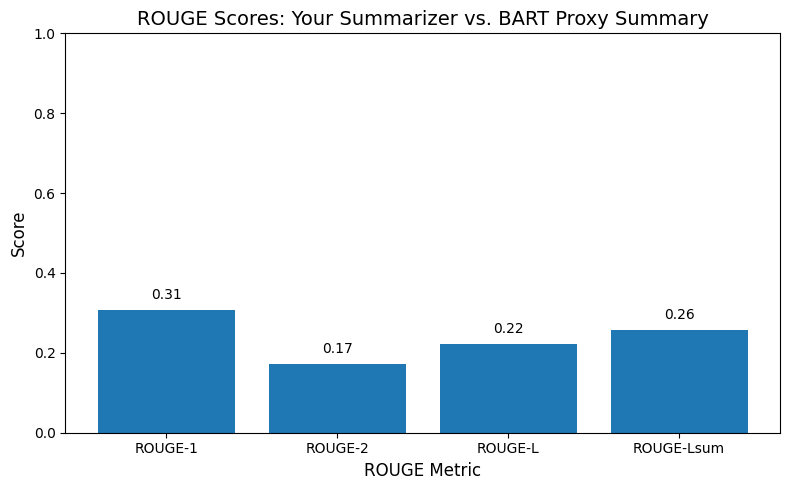

In [54]:
# Use existing 'results' variable
labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'ROUGE-Lsum']
keys = ['rouge1', 'rouge2', 'rougeL', 'rougeLsum']
scores = [float(results[k]) for k in keys]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores)

plt.title("ROUGE Scores: Your Summarizer vs. BART Proxy Summary", fontsize=14)
plt.xlabel("ROUGE Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()



In [55]:
df[['proxy_summary', 'my_summary']].to_csv("summary_comparison.csv", index=False)


storing the frequency of the transformer generated data and adding it as context to our summarizer

In [56]:
contextual_frequency=None
max_frequency=0

for summary in new_df['proxy_summary']:
    contextual_frequency, max_frequency=summarizer.create_word_frequency(summary,contextual_frequency)
   
print(contextual_frequency)
print(max_frequency)

{'bomb': 8.311808881944631e-48, 'exploded': 1.0016112983174515e-53, 'dumpster': 2.767032057022129e-63, 'Chelsea': 4.410389295234445e-11, 'neighborhood': 6.503493541903008e-14, 'New': 5.122321126488608e-10, 'York': 4.3899085189674584e-10, 'City': 8.317976614907199e-07, 'Saturday': 7.472545759585027e-12, 'night': 0.13215866387307348, '29': 5.3005967663206e-19, 'people': 0.0024430398281849895, 'injured': 7.483383882176752e-12, 'explosion': 5.534064114044258e-63, 'released': 2.767032057022129e-63, 'hospital': 5.002072059801559e-54, 'came': 0.007353654405811402, 'heels': 2.767032057022129e-63, 'incident': 2.767032057022129e-63, 'Seaside': 2.767032057022129e-63, 'Heights': 2.767032057022129e-63, 'Jersey': 7.324103053285111e-11, 'Donald': 0.014658239032940166, 'Trump': 0.04397485919991528, 'says': 4.3899085189511893e-10, 'drugs': 2.7643392197892437e-08, '``': 1.0259270362143228e-12, 'big': 1.8845562873767312e-46, 'factor': 5.534064114044258e-63, "'re": 2.1034838934478323e-09, 'watching': 5.53

In [57]:
# Step 2: Generate summaries using your extractive summarizer
def run_trained_summarizer(text):
    return summarizer.summarize(text,contextual_frequency,max_frequency**max_frequency**max_frequency)  # Adjust if your function has a different name

new_df['my_summary_contextual'] = df['text'].apply(run_trained_summarizer)

ROUGE score comparing your summarizer vs. BART proxy summary:
{'rouge1': np.float64(0.3867132082805488), 'rouge2': np.float64(0.2564044570284357), 'rougeL': np.float64(0.2783184452143074), 'rougeLsum': np.float64(0.33785224915499523)}


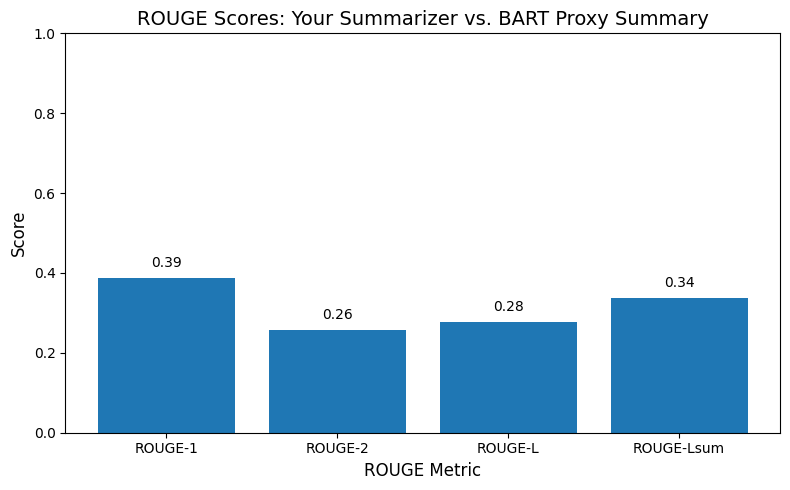

In [58]:
# Step 4: Compute ROUGE score
rouge = evaluate.load("rouge")
results = rouge.compute(
    predictions=new_df['my_summary_contextual'].tolist(),
    references=new_df['proxy_summary'].tolist()
)

print("ROUGE score comparing your summarizer vs. BART proxy summary:")
print(results)

# Use existing 'results' variable
labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'ROUGE-Lsum']
keys = ['rouge1', 'rouge2', 'rougeL', 'rougeLsum']
scores = [float(results[k]) for k in keys]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores)

plt.title("ROUGE Scores: Your Summarizer vs. BART Proxy Summary", fontsize=14)
plt.xlabel("ROUGE Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

new_df.to_csv('trained-output.csv')